**Crawling Berita www.cnnindonesia.com**

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time, re, sys

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import time
import requests
import pandas as pd
from bs4 import BeautifulSoup

# fungsi ambil isi artikel (isi sendiri sesuai kebutuhanmu)
def get_article_content(url):
    r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
    soup = BeautifulSoup(r.text, "html.parser")
    paragraphs = soup.select("div.detail-text p")
    return " ".join(p.get_text(strip=True) for p in paragraphs)

# fungsi progress bar sederhana
def print_progress(current, total):
    print(f"\rHalaman {current}/{total} diproses...", end="")

def berita_cnn(pages=1, save_path="/content/drive/MyDrive/Crawling/cnnindonesia_berita.csv"):
    start_time = time.time()

    BASE_URL = "https://www.cnnindonesia.com/indeks?page={}"

    data = {
        "id_berita": [],
        "judul_berita": [],
        "isi_berita": [],
        "kategori_berita": []
    }

    counter = 1  # mulai id dari 1

    for page in range(1, pages+1):
        url = BASE_URL.format(page)
        r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
        soup = BeautifulSoup(r.text, "html.parser")

        articles = soup.select("article a")
        for a in articles:
            link = a.get("href")
            title = a.get_text(strip=True)

            if not link or not title:
                continue
            if not link.startswith("https://www.cnnindonesia.com/"):
                continue

            # Ambil kategori dari URL
            try:
                kategori = link.split("/")[3]
            except:
                kategori = "unknown"

            try:
                content = get_article_content(link)
            except:
                content = ""

            data["id_berita"].append(counter)
            data["judul_berita"].append(title)
            data["isi_berita"].append(content)
            data["kategori_berita"].append(kategori)

            counter += 1  # naikkan id

        print_progress(page, pages)

    df = pd.DataFrame(data)
    df.to_csv(save_path, index=False, encoding="utf-8-sig")

    end_time = time.time()
    elapsed = int(end_time - start_time)
    jam, sisa = divmod(elapsed, 3600)
    menit, detik = divmod(sisa, 60)

    print("\nSeluruh data berhasil dikumpulkan!")
    print(f"Total entri: {len(df)}")
    print(f"Waktu eksekusi: {jam} jam {menit} menit {detik} detik")
    print(f"File disimpan di: {save_path}")

    return df


# Pemanggilan
berita_path = "/content/drive/MyDrive/Crawling/cnnindonesia_berita.csv"
df_cnn = berita_cnn(pages=100, save_path=berita_path)

# Membaca kembali file
berita = pd.read_csv(berita_path, index_col="id_berita")
berita.head()


Halaman 100/100 diproses...
Seluruh data berhasil dikumpulkan!
Total entri: 1000
Waktu eksekusi: 0 jam 11 menit 1 detik
File disimpan di: /content/drive/MyDrive/Crawling/cnnindonesia_berita.csv


,judul_berita,isi_berita,kategori_berita
id_berita,,,
1,PM Qatar Desak Dunia Setop Pakai Standar Ganda...,Perdana MenteriQatarSheikh Mohammed bin Abdulr...,internasional
2,"Pengadilan Tak Mau Hukum Pengedar Miras, Akhir...",Sejarah pengambilalihan aset oleh pemerintahAm...,internasional
3,"Hasil Liga Inggris: Man City Bantai MU, Haalan...",Manchester Cityberhasil membantaiManchester Un...,olahraga
4,Danau Terbesar di Inggris Raya 'Sekarat' Akiba...,"Danau terbesar diInggris Raya, Lough Neagh, di...",internasional
5,Rizky Ridho Ungkap Niat Main di Luar Negeri: T...,"KaptenPersija Jakarta,Rizky Ridhomembuka dialo...",olahraga


In [11]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time, re, sys

# web struktur

**Page & Link Output Berita**

In [15]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time, sys

# progress bar
def print_progress(current_page, total_pages):
    percent = (current_page / total_pages) * 100
    bar_length = 20
    filled_length = int(bar_length * current_page // total_pages)
    bar = '█' * filled_length + '-' * (bar_length - filled_length)
    sys.stdout.write(f'\rPage {current_page}/{total_pages} [{bar}] {percent:.2f}%')
    sys.stdout.flush()
    if current_page == total_pages:
        sys.stdout.write('\n\n')

# fungsi untuk kumpulkan link berita CNN Indonesia
def berita_links(pages=1, save_path="/content/drive/MyDrive/Crawling/cnnindonesia_links1.csv"):
    start_time = time.time()

    BASE_URL = "https://www.cnnindonesia.com/indeks?page={}"

    data = {
        "id_berita": [],
        "page": [],
        "link_keluar": []
    }

    counter = 1
    for page in range(1, pages+1):
        url = BASE_URL.format(page)
        r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
        soup = BeautifulSoup(r.text, "html.parser")

        articles = soup.select("article a")
        for a in articles:
            link = a.get("href")

            if not link or not link.startswith("https://www.cnnindonesia.com/"):
                continue

            data["id_berita"].append(counter)
            data["page"].append(url)       # halaman indeks
            data["link_keluar"].append(link)  # link detail berita

            counter += 1

        print_progress(page, pages)

    # simpan ke drive
    df = pd.DataFrame(data)
    df.to_csv(save_path, index=False, encoding="utf-8-sig")

    end_time = time.time()
    elapsed = int(end_time - start_time)
    jam, sisa = divmod(elapsed, 3600)
    menit, detik = divmod(sisa, 60)

    print("\nSeluruh link berhasil dikumpulkan!")
    print(f"Total entri: {len(df)}")
    print(f"Waktu eksekusi: {jam} jam {menit} menit {detik} detik")
    print(f"File tersimpan di: {save_path}")

    return df


# contoh pemanggilan: ambil 100 halaman pertama
link_path = "/content/drive/MyDrive/Crawling/cnnindonesia_links1.csv"
df_links = berita_links(pages=100, save_path=link_path)

# baca kembali dari drive
berita_links_df = pd.read_csv(link_path, index_col="id_berita")
berita_links_df.head()


Page 100/100 [████████████████████] 100.00%


Seluruh link berhasil dikumpulkan!
Total entri: 1000
Waktu eksekusi: 0 jam 0 menit 56 detik
File tersimpan di: /content/drive/MyDrive/Crawling/cnnindonesia_links1.csv


,page,link_keluar
id_berita,,
1,https://www.cnnindonesia.com/indeks?page=1,https://www.cnnindonesia.com/internasional/202...
2,https://www.cnnindonesia.com/indeks?page=1,https://www.cnnindonesia.com/internasional/202...
3,https://www.cnnindonesia.com/indeks?page=1,https://www.cnnindonesia.com/olahraga/20250914...
4,https://www.cnnindonesia.com/indeks?page=1,https://www.cnnindonesia.com/internasional/202...
5,https://www.cnnindonesia.com/indeks?page=1,https://www.cnnindonesia.com/olahraga/20250914...


Jumlah link unik di homepage: 84


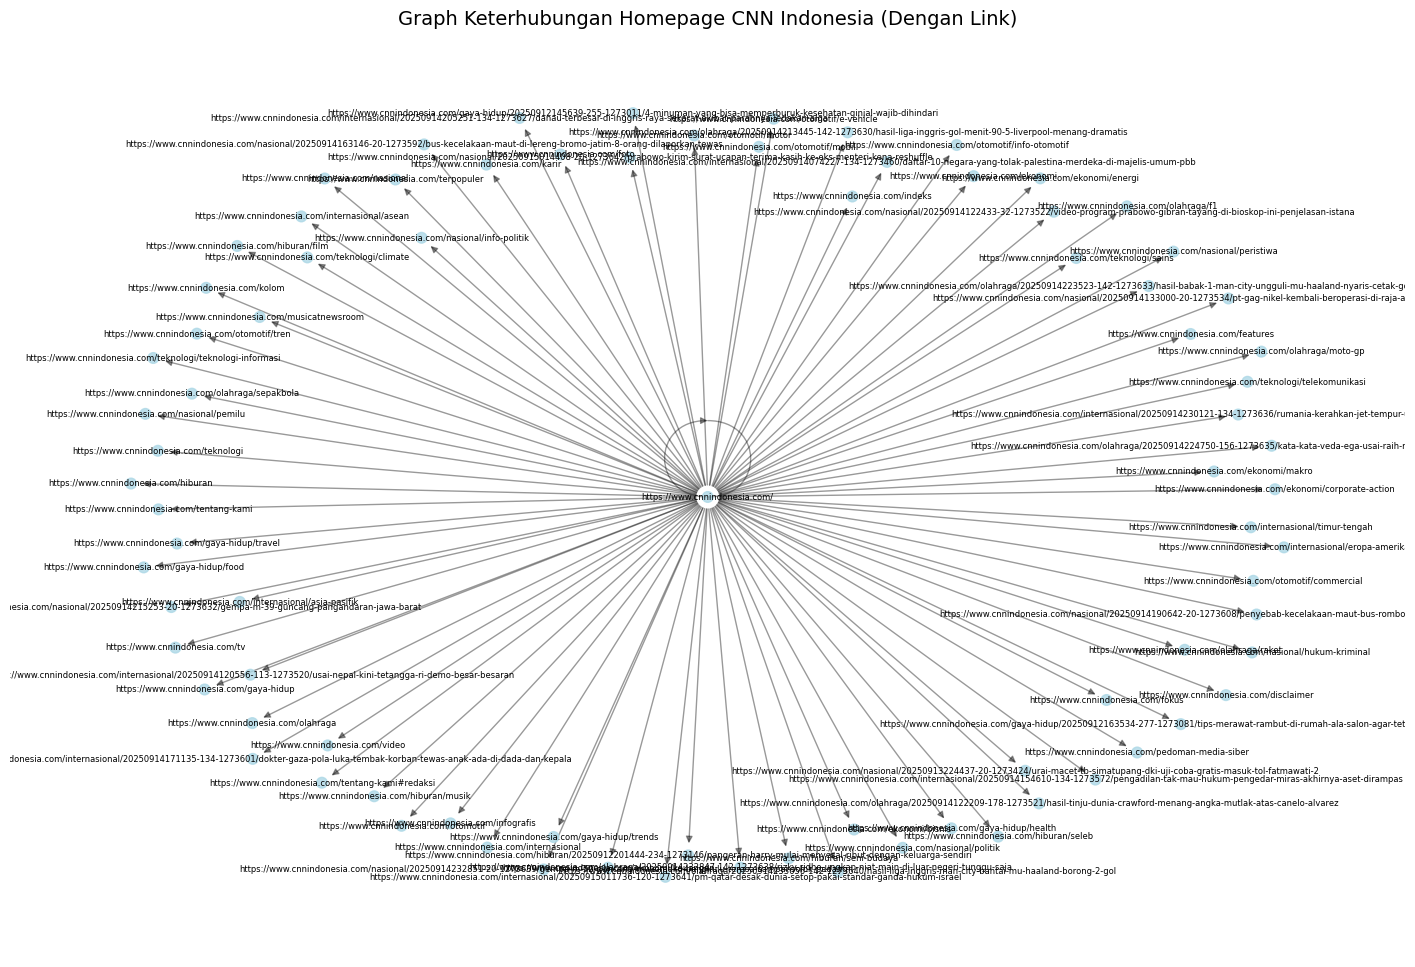

In [20]:
import requests
from bs4 import BeautifulSoup
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. Crawl homepage CNN Indonesia ---
BASE_URL = "https://www.cnnindonesia.com/"
r = requests.get(BASE_URL, headers={"User-Agent": "Mozilla/5.0"})
soup = BeautifulSoup(r.text, "html.parser")

# --- 2. Ambil semua link dari homepage ---
links = set()
for a in soup.find_all("a", href=True):
    href = a["href"]
    if href.startswith("https://www.cnnindonesia.com/"):
        links.add(href)

print(f"Jumlah link unik di homepage: {len(links)}")

# --- 3. Bangun graph keterhubungan ---
G = nx.DiGraph()

# Tambahkan edge: homepage -> link
for link in links:
    G.add_edge(BASE_URL, link)

# --- 4. Hitung PageRank ---
pagerank_scores = nx.pagerank(G, alpha=0.85)

# --- 5. Visualisasi graph ---
plt.figure(figsize=(18, 12))
pos = nx.spring_layout(G, k=0.4, seed=42)

# gambar edge
nx.draw_networkx_edges(G, pos, alpha=0.4, arrows=True)

# gambar node: ukuran sesuai PageRank
nx.draw_networkx_nodes(
    G, pos,
    node_size=[v * 5000 for v in pagerank_scores.values()],
    node_color="lightblue",
    alpha=0.8
)

# gambar label: tuliskan URL node
nx.draw_networkx_labels(
    G, pos,
    labels={n: n for n in G.nodes()},   # full link
    font_size=6
)

plt.title("Graph Keterhubungan Homepage CNN Indonesia (Dengan Link)", fontsize=14)
plt.axis("off")
plt.show()


[Lanjut ke Preprocessing](preprocessing.ipynb)
